# Task 8 — The Sidewalk Illusion (Projective / Perspective)

**Scenario:** a photo of 3D chalk art on a sidewalk was taken at an angle, so the far edge of the art looks smaller than the close edge.

**Approach:** pick the 4 corners of the art that should mathematically form a perfect square. A perspective map has 8 unknowns:

$$x' = \frac{h_{11}x + h_{12}y + h_{13}}{h_{31}x + h_{32}y + 1}, \qquad y' = \frac{h_{21}x + h_{22}y + h_{23}}{h_{31}x + h_{32}y + 1}$$

Cross-multiplying turns each of the 4 point correspondences into 2 linear equations, giving an 8x8 linear system that is solved directly (no `cv2.getPerspectiveTransform` shortcut) to recover the matrix and warp the art into a top-down view.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)
np.set_printoptions(precision=3, suppress=True)

In [2]:
def compute_homography(src_pts, dst_pts):
    A = np.zeros((8, 8))
    b = np.zeros(8)
    for i in range(4):
        x, y = src_pts[i]
        xp, yp = dst_pts[i]
        A[2 * i]     = [x, y, 1, 0, 0, 0, -x * xp, -y * xp]
        A[2 * i + 1] = [0, 0, 0, x, y, 1, -x * yp, -y * yp]
        b[2 * i] = xp
        b[2 * i + 1] = yp
    h = np.linalg.solve(A, b)
    H = np.array([[h[0], h[1], h[2]],
                  [h[3], h[4], h[5]],
                  [h[6], h[7], 1.0]])
    return H, A, b

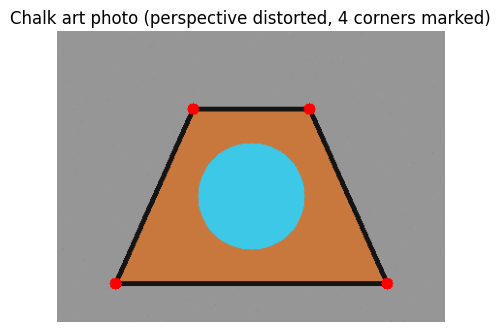

In [3]:
def make_sidewalk_scene(w=400, h=300):
    img = np.full((h, w, 3), (150, 150, 150), dtype=np.uint8)
    rng = np.random.default_rng(4)
    for _ in range(400):
        x, y = rng.integers(0, w), rng.integers(0, h)
        shade = rng.integers(-15, 15)
        img[y, x] = np.clip(img[y, x].astype(int) + shade, 0, 255)
    corners = np.array([[140, 80], [260, 80], [340, 260], [60, 260]], dtype=np.float32)
    art = img.copy()
    cv2.fillConvexPoly(art, corners.astype(int), (60, 120, 200))
    cv2.circle(art, (200, 170), 55, (230, 200, 60), -1)
    cv2.polylines(art, [corners.astype(int)], True, (20, 20, 20), 3)
    return art, corners

sidewalk, art_corners = make_sidewalk_scene()
cv2.imwrite('data_sidewalk.png', sidewalk)
annotated = sidewalk.copy()
for (x, y) in art_corners:
    cv2.circle(annotated, (int(x), int(y)), 6, (0, 0, 255), -1)

plt.figure(figsize=(5, 4))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title('Chalk art photo (perspective distorted, 4 corners marked)')
plt.axis('off')
plt.savefig('output/00_sidewalk_annotated.png', bbox_inches='tight', dpi=150)
plt.show()

Perspective matrix H =
 [[   4.5      2.727 -750.   ]
 [   0.       7.727 -520.   ]
 [  -0.       0.018    1.   ]]


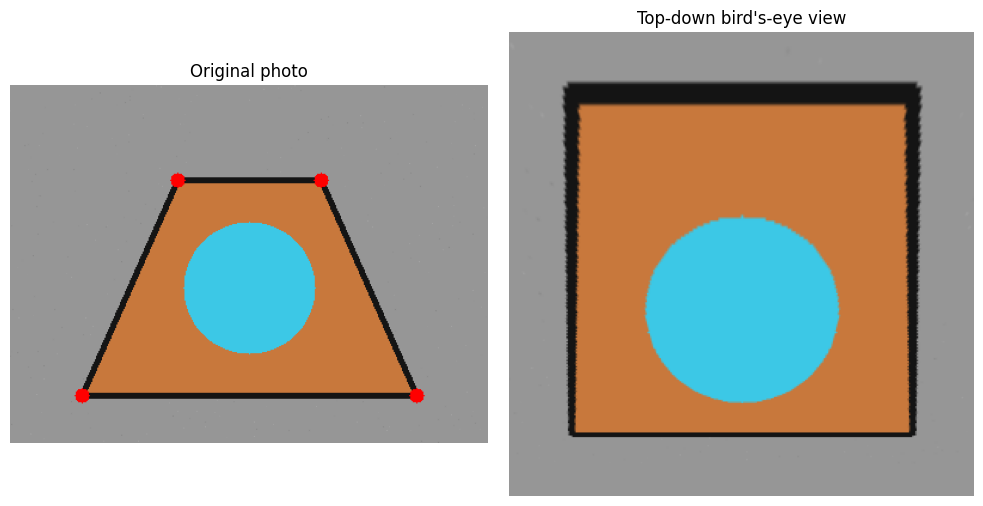

In [4]:
square_size = 220
out_w, out_h = 300, 300
pad = (out_w - square_size) / 2
dst_square = np.array([
    [pad, pad],
    [pad + square_size, pad],
    [pad + square_size, pad + square_size],
    [pad, pad + square_size]
], dtype=np.float32)

H, A, b = compute_homography(art_corners, dst_square)
print('Perspective matrix H =\n', H)

birdseye = cv2.warpPerspective(sidewalk, H, (out_w, out_h), borderValue=(150, 150, 150))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original photo')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(birdseye, cv2.COLOR_BGR2RGB))
axes[1].set_title('Top-down bird\'s-eye view')
axes[1].axis('off')
plt.tight_layout()
plt.savefig('output/01_birdseye.png', bbox_inches='tight', dpi=150)
plt.show()